# SHAP Explanations on a Dataset with Known Signal and Noise

## Goal

Train a nonlinear classifier on synthetic data whose informative, redundant, and
noise features are known; then use SHAP to check whether global and local
explanations recover that structure.

A synthetic dataset avoids publishing the course folder's unattributed Adult
Income CSV and makes the explanation audit falsifiable: pure-noise features should
matter much less than the constructed signal.

## Setup

Install `requirements-course-demos.txt`. The notebook generates all observations
locally and makes no network requests. SHAP explains the fitted model, not the
real-world process that a feature name might suggest.

In [1]:
from pathlib import Path
import os

MPL_CACHE = Path("data/matplotlib")
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE.resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

print(f"shap={shap.__version__}; seed={SEED}")

shap=0.52.0; seed=42


## Steps

### 1. Generate data with documented feature roles

In [2]:
values, target = make_classification(
    n_samples=2_000,
    n_features=8,
    n_informative=4,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    class_sep=1.2,
    flip_y=0.03,
    shuffle=False,
    random_state=SEED,
)

feature_names = [
    "signal_1",
    "signal_2",
    "signal_3",
    "signal_4",
    "redundant_1",
    "redundant_2",
    "noise_1",
    "noise_2",
]
features = pd.DataFrame(values, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.25,
    stratify=target,
    random_state=SEED,
)

pd.DataFrame(
    {
        "feature": feature_names,
        "known_role": ["informative"] * 4 + ["redundant"] * 2 + ["noise"] * 2,
    }
)

,feature,known_role
0,signal_1,informative
1,signal_2,informative
2,signal_3,informative
3,signal_4,informative
4,redundant_1,redundant
5,redundant_2,redundant
6,noise_1,noise
7,noise_2,noise


### 2. Fit and evaluate a random forest

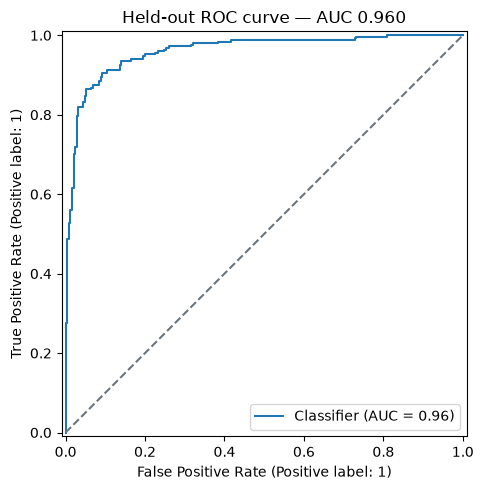

accuracy=0.900; ROC AUC=0.960


In [3]:
model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=SEED,
)
model.fit(X_train, y_train)

test_probabilities = model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)
accuracy = accuracy_score(y_test, test_predictions)
auc = roc_auc_score(y_test, test_probabilities)

fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="#6c757d")
ax.set_title(f"Held-out ROC curve — AUC {auc:.3f}")
plt.tight_layout()
plt.show()

print(f"accuracy={accuracy:.3f}; ROC AUC={auc:.3f}")

### 3. Compute class-1 SHAP values on a bounded held-out sample

Tree SHAP decomposes each model prediction into a baseline plus per-feature
contributions. Positive values push this forest toward class 1; negative values
push it toward class 0.

In [4]:
explanation_sample = X_test.iloc[:250].copy()
raw_explanation = shap.TreeExplainer(model)(explanation_sample)

if raw_explanation.values.ndim == 3:
    class_one_explanation = shap.Explanation(
        values=raw_explanation.values[:, :, 1],
        base_values=np.asarray(raw_explanation.base_values)[:, 1],
        data=raw_explanation.data,
        feature_names=raw_explanation.feature_names,
    )
else:
    class_one_explanation = raw_explanation

mean_absolute_shap = pd.Series(
    np.abs(class_one_explanation.values).mean(axis=0),
    index=feature_names,
    name="mean_absolute_shap",
).sort_values(ascending=False)

mean_absolute_shap.to_frame().style.format("{:.4f}")

,mean_absolute_shap
redundant_1,0.1071
signal_1,0.0868
signal_3,0.0765
signal_2,0.0699
redundant_2,0.0565
signal_4,0.0488
noise_2,0.0050
noise_1,0.0049


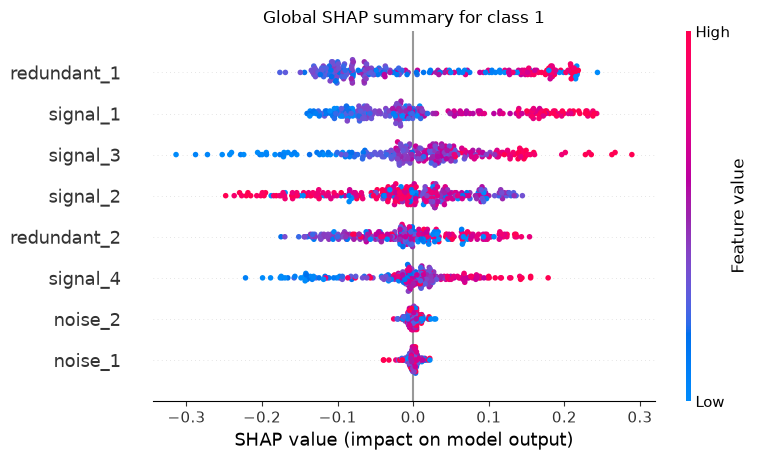

In [5]:
shap.plots.beeswarm(class_one_explanation, max_display=8, show=False)
plt.title("Global SHAP summary for class 1")
plt.tight_layout()
plt.show()

### 4. Inspect one high-confidence local prediction

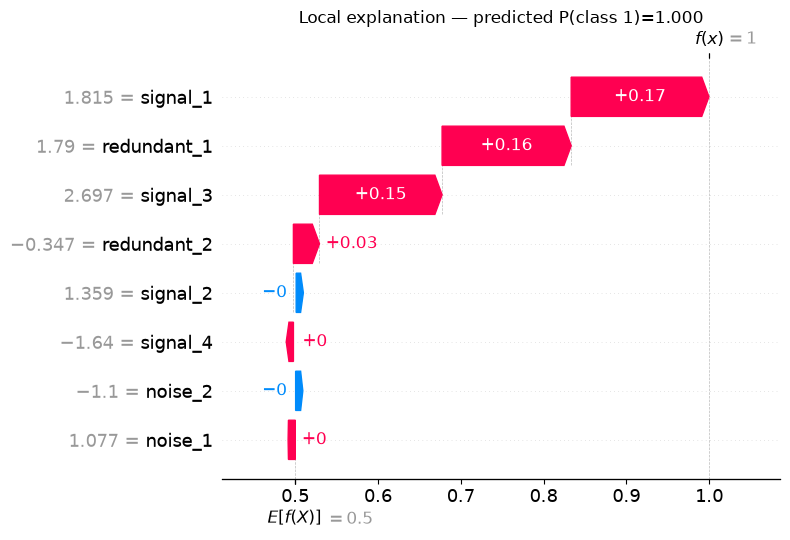

In [6]:
sample_probabilities = model.predict_proba(explanation_sample)[:, 1]
local_position = int(np.argmax(sample_probabilities))

shap.plots.waterfall(class_one_explanation[local_position], max_display=8, show=False)
plt.title(f"Local explanation — predicted P(class 1)={sample_probabilities[local_position]:.3f}")
plt.tight_layout()
plt.show()

## Checks

In [7]:
reconstructed_probabilities = (
    np.asarray(class_one_explanation.base_values)
    + np.asarray(class_one_explanation.values).sum(axis=1)
)
additivity_error = np.max(np.abs(sample_probabilities - reconstructed_probabilities))

signal_importance = mean_absolute_shap[[name for name in feature_names if not name.startswith("noise")]].mean()
noise_importance = mean_absolute_shap[["noise_1", "noise_2"]].mean()

assert auc > 0.90
assert additivity_error < 1e-8
assert signal_importance > 5 * noise_importance
assert np.isfinite(class_one_explanation.values).all()

print(
    f"Checks passed: AUC={auc:.3f}; maximum SHAP additivity error={additivity_error:.2e}; "
    f"signal/noise importance ratio={signal_importance / noise_importance:.1f}."
)

Checks passed: AUC=0.960; maximum SHAP additivity error=2.55e-15; signal/noise importance ratio=14.9.


## Next Steps

- Add correlated proxies and observe how credit is shared across features.
- Compare SHAP with permutation importance and partial dependence.
- Repeat explanations across model seeds and held-out samples to measure stability.
- For real people or consequential decisions, document data provenance, subgroup error, and whether a feature is appropriate—not merely influential.

SHAP faithfully decomposes this fitted forest's output to numerical precision.
That is a statement about model behavior, not causality, fairness, or whether the
model should be used.